## Connecting to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Moving Files from Drive to Colab for faster execution

In [2]:
!cp -r /content/drive/MyDrive/ContentRecognition/video_dataset /content/

## verify dataset structure

In [3]:
import os

ucf_path = '/content/video_dataset'
all_classes = sorted(os.listdir(ucf_path))

print(f"Total classes: {len(all_classes)}")
print("\nAll available classes:")
for i, cls in enumerate(all_classes):
    print(f"{i+1:3}. {cls}")

Total classes: 10

All available classes:
  1. Basketball
  2. Biking
  3. Bowling
  4. CliffDiving
  5. GolfSwing
  6. HorseRiding
  7. SkateBoarding
  8. Skiing
  9. Surfing
 10. TennisSwing


## Importing Libraries

In [ ]:
import cv2
import os
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

## Paths of dataset and extracted frames 

In [ ]:
ucf_path = '/content/video_dataset'
frames_path = '/content/ucf_frames'
os.makedirs(frames_path, exist_ok=True)

## Select action classes

In [ ]:
selected_classes = [
    'Basketball',
    'Biking',
    'Bowling',
    'CliffDiving',
    'GolfSwing',
    'HorseRiding',
    'Skiing',
    'Surfing',
    'TennisSwing',
    'SkateBoarding'
]

## Extract 16 frames per video

In [ ]:
FRAMES_PER_VIDEO = 16  

def extract_frames(video_path, output_folder, num_frames=16):
    cap = cv2.VideoCapture(video_path)                      # Reads video file
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))   # count total no. of frames

    if total_frames == 0:
        cap.release()
        return False

    # Pick evenly spaced frame indices
    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    saved = 0
    frame_idx = 0

    while cap.isOpened():           # Read video frame-by-frame
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx in indices:
            frame = cv2.resize(frame, (224, 224))               # Resize frame
            cv2.imwrite(os.path.join(output_folder, f'frame_{saved:03d}.jpg'), frame)   # Save frame as image
            saved += 1
        frame_idx += 1

    cap.release()
    return saved == num_frames


Processing Basketball — 134 videos


100%|██████████| 134/134 [00:05<00:00, 23.34it/s]


  Successfully extracted: 116/134

Processing Biking — 134 videos


100%|██████████| 134/134 [00:09<00:00, 13.62it/s]


  Successfully extracted: 120/134

Processing Bowling — 155 videos


...

  Successfully extracted: 126/126

Processing TennisSwing — 166 videos


100%|██████████| 166/166 [00:07<00:00, 21.01it/s]


  Successfully extracted: 141/166

Processing SkateBoarding — 120 videos


100%|██████████| 120/120 [00:05<00:00, 21.31it/s]

  Successfully extracted: 120/120

Frame extraction complete!


## Extract frames for selected classes

In [ ]:
# Process all classes and all videos
for cls in selected_classes:
    cls_video_path  = os.path.join(ucf_path, cls)
    cls_frames_path = os.path.join(frames_path, cls)
    os.makedirs(cls_frames_path, exist_ok=True)

    videos = os.listdir(cls_video_path)
    print(f"\nProcessing {cls} — {len(videos)} videos")

    success = 0
    # For every video: create separate folder & extract frames
    for video in tqdm(videos):
        video_path  = os.path.join(cls_video_path, video)
        video_name  = os.path.splitext(video)[0]
        output_dir  = os.path.join(cls_frames_path, video_name)
        os.makedirs(output_dir, exist_ok=True)

        if extract_frames(video_path, output_dir):
            success += 1

    print(f"  Successfully extracted: {success}/{len(videos)}")

print("\nFrame extraction complete!")

## Convert frames into tensors

In [ ]:
class VideoFrameDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    # Returns total number of videos
    def __len__(self):
        return len(self.samples)

    # This loads ONE video sample.
    def __getitem__(self, idx):
        video_path, label = self.samples[idx]       # Get video folder path and label
        frames = sorted(os.listdir(video_path))     # Read all frames

        frame_tensors = []
        for frame_file in frames:                               # Loop through frames, Processes all 16 frames
            frame_path = os.path.join(video_path, frame_file)
            image      = Image.open(frame_path).convert('RGB')  # Load image
            if self.transform:
                image = self.transform(image)                   # Apply transforms(Resize, normalize, tensor conversion)
            frame_tensors.append(image)                         # Store tensors, Each frame becomes (3, 224, 224)

        video_tensor = torch.stack(frame_tensors)               # Stack frames, Combines all frames into ONE tensor
                                                                # Shape becomes: (16, 3, 224, 224)
        return video_tensor, label                              # ONE sample now contains: 16-frame video + action label

Total valid videos: 1328
Train: 1062 | Val: 266


## Build dataset samples manually

In [ ]:
selected_classes = [
    'Basketball', 'Biking', 'Bowling', 'CliffDiving',
    'GolfSwing', 'HorseRiding', 'Skiing', 'Surfing',
    'TennisSwing', 'SkateBoarding'
]

frames_path = '/content/ucf_frames'
class_to_idx = {cls: idx for idx, cls in enumerate(selected_classes)}

all_samples = []
for cls in selected_classes:
    cls_path = os.path.join(frames_path, cls)
    if not os.path.exists(cls_path):
        print(f"Missing: {cls}")
        continue
    for video_name in os.listdir(cls_path):
        video_path = os.path.join(cls_path, video_name)
        frames     = os.listdir(video_path)
        if len(frames) == 16:                                       # Keeps only videos with exactly 16 frames
            all_samples.append((video_path, class_to_idx[cls]))     # Each sample:(video folder path, label)

print(f"Total valid videos: {len(all_samples)}")

In [ ]:
# Image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Manual train/val split
import random
random.shuffle(all_samples)
split       = int(0.8 * len(all_samples))       # Train-validation split(80% training, 20% validation)
train_samples = all_samples[:split]
val_samples   = all_samples[split:]

# Create datasets (Now datasets can load videos as tensors)
train_dataset = VideoFrameDataset(train_samples, transform=transform)
val_dataset   = VideoFrameDataset(val_samples,   transform=transform)

# Create dataloaders (Creates batches of videos)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

In [ ]:

class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=10, hidden_size=512, num_layers=2):
        super(CNN_LSTM, self).__init__()

        # CNN — pretrained ResNet50 as feature extractor
        resnet = models.resnet50(pretrained=True)

        # Freeze everything first (Prevents CNN training)
        for param in resnet.parameters():
            param.requires_grad = False

        # Unfreeze ONLY layer4 (last block)
        for name, param in resnet.named_parameters():
            if 'layer4' in name:
                param.requires_grad = True

        # Remove final FC layer
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])

        # Freeze CNN layers
        # for param in self.cnn.parameters():
        #     param.requires_grad = False

        # LSTM — takes CNN features as sequence
        self.lstm = nn.LSTM(
            input_size  = 2048,         # ResNet50 output size
            hidden_size = hidden_size,  # LSTM memory representation size (512)
            num_layers  = num_layers,   # 2 stacked LSTM layers
            batch_first = True,
            dropout     = 0.3
        )

        # Final classifier (512 → 256 → 10 classes)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):               # Input - (batch, frames, C, H, W) = (8, 16, 3, 224, 224) i.e 8 videos, 16 frames each
        # x shape: (batch, frames, C, H, W)
        batch_size, frames, C, H, W = x.shape

        # Reshape to process all frames through CNN
        x = x.view(batch_size * frames, C, H, W)        # (8,16,3,224,224) → (128,3,224,224)
        # As CNN processes images individually.

        # CNN feature extraction
        cnn_features = self.cnn(x)  # (128, 2048, 1, 1)

        # Reshape again
        cnn_features = cnn_features.view(batch_size, frames, -1)  # (8, 16, 2048)
        # 16 frame features per video

        # LSTM temporal modeling (LSTM processes frame sequence)
        lstm_out, _ = self.lstm(cnn_features)  # (batch, frames, hidden_size) = (8, 16, 512)

        # Take last frame output
        last_output = lstm_out[:, -1, :]  # (batch, hidden_size) = (8, 512)

        # Classify
        out = self.classifier(last_output)     # (batch, 10) - One score per action class.
        return out

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = CNN_LSTM(num_classes=10).to(device)
print("CNN+LSTM Model ready!")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


CNN+LSTM Model ready!
Trainable parameters: 7,482,122


In [ ]:
criterion = nn.CrossEntropyLoss()       # Loss function
optimizer = optim.Adam(                 # Optimizer
    filter(lambda p: p.requires_grad, model.parameters()),      # Only trains parameters where requires_grad = True
    lr=0.0001                    # ← changed
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)    # Reduces learning rate every 5 epochs by × 0.1

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_acc    = 0.0
EPOCHS          = 10             # ← changed
checkpoint_path = '/content/drive/MyDrive/ContentRecognition/checkpoints/cnn_lstm_best.pth'

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            loader = train_loader
        else:
            model.eval()
            loader = val_loader

        running_loss     = 0.0
        running_corrects = 0

        for inputs, labels in loader:       # inputs → videos, labels → action classes
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()           # Clear old gradients

            with torch.set_grad_enabled(phase == 'train'):
                outputs        = model(inputs)                  # Forward pass
                loss           = criterion(outputs, labels)     # Compute loss
                _, preds       = torch.max(outputs, 1)          # Chooses highest score class.

                if phase == 'train':
                    loss.backward()             # Backpropagation
                    optimizer.step()            # Weight update

            # Track performance
            running_loss     += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()        # Adjusts learning rate after epoch.

        # Compute epoch metrics
        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc  = running_corrects.double() / len(loader.dataset)

        print(f"{phase.upper()} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        # Save history
        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

            # Save BEST model
            if epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                torch.save(model.state_dict(), checkpoint_path)             # Save weights
                print(f"  ✅ Best model saved! Val Acc: {best_val_acc:.4f}")

print(f"\nTraining Complete! Best Val Acc: {best_val_acc:.4f}")


Epoch 1/10
----------------------------------------
TRAIN — Loss: 1.8624  Acc: 0.3917
VAL — Loss: 1.0408  Acc: 0.6729
  ✅ Best model saved! Val Acc: 0.6729

Epoch 2/10
----------------------------------------
TRAIN — Loss: 1.0489  Acc: 0.6497
VAL — Loss: 0.5492  Acc: 0.8797
  ✅ Best model saved! Val Acc: 0.8797

Epoch 3/10
----------------------------------------
TRAIN — Loss: 0.7283  Acc: 0.7674
VAL — Loss: 0.6375  Acc: 0.8008

Epoch 4/10
----------------------------------------
TRAIN — Loss: 0.6686  Acc: 0.7815
VAL — Loss: 0.3293  Acc: 0.8947
  ✅ Best model saved! Val Acc: 0.8947

Epoch 5/10
----------------------------------------
TRAIN — Loss: 0.4784  Acc: 0.8409
VAL — Loss: 0.4230  Acc: 0.8647

Epoch 6/10
----------------------------------------
TRAIN — Loss: 0.3404  Acc: 0.9058
VAL — Loss: 0.1682  Acc: 0.9549
  ✅ Best model saved! Val Acc: 0.9549

Epoch 7/10
----------------------------------------
TRAIN — Loss: 0.2324  Acc: 0.9379
VAL — Loss: 0.1358  Acc: 0.9624
  ✅ Best model 

Classification Report:
               precision    recall  f1-score   support

   Basketball       1.00      1.00      1.00        27
       Biking       1.00      0.97      0.98        29
      Bowling       1.00      1.00      1.00        23
  CliffDiving       1.00      1.00      1.00        25
    GolfSwing       0.91      0.95      0.93        21
  HorseRiding       1.00      0.94      0.97        31
       Skiing       1.00      1.00      1.00        27
      Surfing       1.00      1.00      1.00        28
  TennisSwing       0.90      0.93      0.92        30
SkateBoarding       0.92      0.96      0.94        25

     accuracy                           0.97       266
    macro avg       0.97      0.97      0.97       266
 weighted avg       0.97      0.97      0.97       266



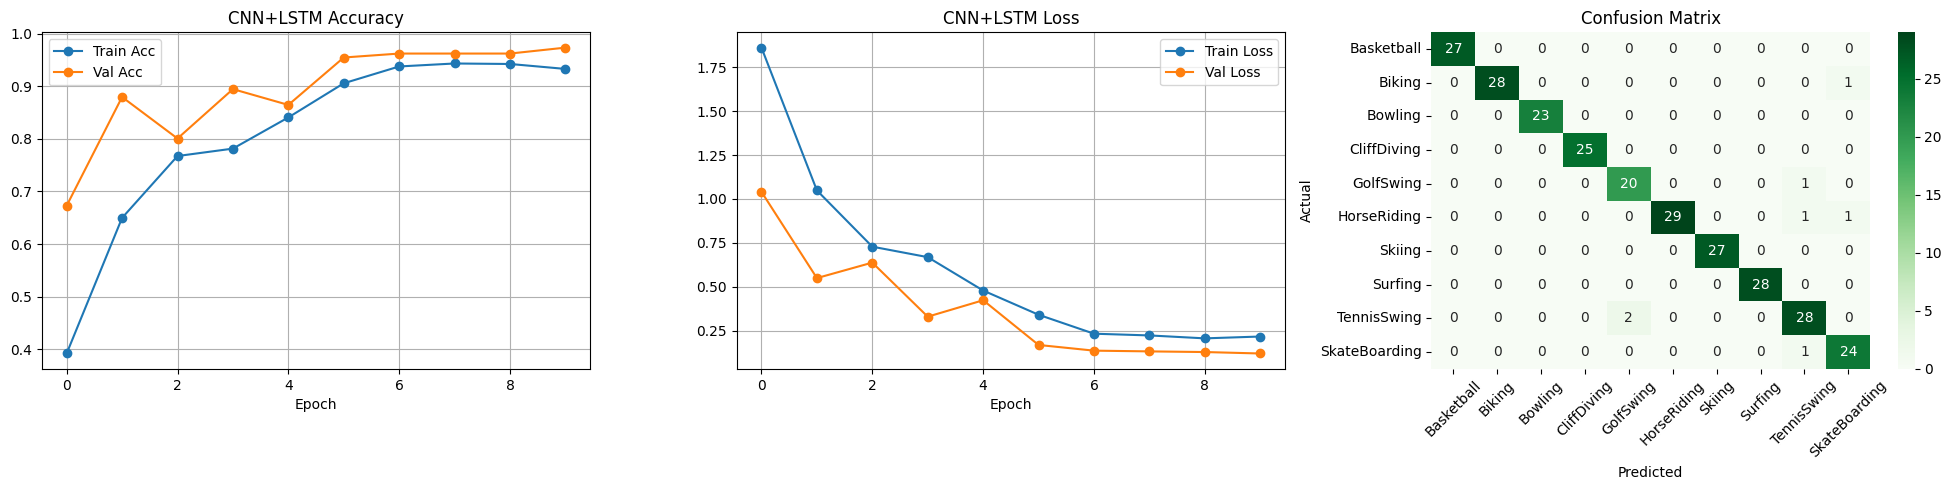

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs  = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=selected_classes))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(history['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[0].set_title('CNN+LSTM Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[1].set_title('CNN+LSTM Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=selected_classes,
            yticklabels=selected_classes, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ContentRecognition/cnn_lstm_results.png', dpi=150)
plt.show()